# SPORTS CAR PRICES ANALYSIS - AUTOMOTIVE LUXURY ANALYTICS

## Dataset: Sports Car Prices Dataset
**Kaynak:** https://www.kaggle.com/datasets/rkiattisak/sports-car-prices-dataset

## Proje Hedefi: LUKSUZ OTOMOBIL PIYASA ANALIZI

## Proje Ozellikleri:
- **Luxury Car Market** - Premium segment analysis
- **Brand Intelligence** - Manufacturer comparison
- **Performance Metrics** - Horsepower, torque, acceleration
- **Engine Specifications** - Technical analysis
- **Price Segmentation** - Market positioning
- **Value Analysis** - Price-performance ratio
- **15+ ML Models** - RBFSampler+LogisticRegression instead of SVM!
- **Automotive Intelligence** - Market insights

## MEGA OZEL: RBFSampler + LogisticRegression - SVM yerine!
## Kernel Approximation with Random Fourier Features!
## Non-linear power + Linear speed = BEST of both worlds!

## Proje Adimlari:
1. Veri Yukleme & Automotive Structure
2. **BRAND EDA** (25+ graphs)
3. **PRICE ANALYSIS**
4. **PERFORMANCE METRICS**
5. **ENGINE SPECIFICATIONS**
6. **MARKET SEGMENTATION**
7. Feature Engineering (Automotive-specific)
8. **15+ ML MODELS** (with Kernel Approximation!)
9. **COMPREHENSIVE COMPARISON**
10. Automotive Market Recommendations

## 1. KUTUPHANELER

In [2]:
# Temel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sistem
import os
import subprocess
import zipfile
import glob

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.kernel_approximation import RBFSampler  # KERNEL APPROXIMATION!
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline  # For RBF + LR pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Install CatBoost if not already installed
try:
    import catboost
except ImportError:
    %pip install catboost --quiet
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Viz
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('='*80)
print('SPORTS CAR PRICES ANALYSIS - KUTUPHANELER YUKLENDI!')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print('\nMEGA OZEL: RBFSampler + LogisticRegression - SVM YERINE!')
print('Kernel Approximation with Random Fourier Features!')
print('Approximates RBF kernel SVM but MUCH faster!')
print('Non-linear transformations + Linear model = Perfect combo!')
print('='*80)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00
SPORTS CAR PRICES ANALYSIS - KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2

MEGA OZEL: RBFSampler + LogisticRegression - SVM YERINE!
Kernel Approximation with Random Fourier Features!
Approximates RBF kernel SVM but MUCH faster!
Non-linear transformations + Linear model = Perfect combo!


## 2. VERI YUKLEME

In [3]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"Indiriliyor: {zip_filename}")
    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [4]:
dataset_folder = "sportscar_prices_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/rkiattisak/sports-car-prices-dataset",
    "folder": dataset_folder,
    "zip_filename": "sportscar-prices.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset mevcut!")

Indiriliyor: sportscar-prices.zip


In [5]:
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[0])

    print('='*80)
    print('SPORTS CAR DATA LOADED!')
    print('='*80)
    print(f'Total Cars: {len(df):,}')
    print(f'Columns: {len(df.columns)}')
    print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*80)
else:
    print('CSV not found!')

SPORTS CAR DATA LOADED!
Total Cars: 1,007
Columns: 8
Memory: 0.37 MB


In [6]:
print('FIRST 10 CARS:')
df.head(10)

FIRST 10 CARS:


,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
5,BMW,M8,2022,4.4,617,553,3.1,"130,000"
6,Mercedes-Benz,AMG GT,2021,4,523,494,3.8,"118,500"
7,Chevrolet,Corvette,2021,6.2,490,465,2.8,"59,900"
8,Ford,Mustang Shelby GT500,2022,5.2,760,625,3.5,"81,000"
9,Nissan,GT-R Nismo,2021,3.8,600,481,2.5,"212,000"


In [7]:
print('DATA STRUCTURE:')
print('='*80)
df.info()

DATA STRUCTURE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Car Make                 1007 non-null   object
 1   Car Model                1007 non-null   object
 2   Year                     1007 non-null   int64 
 3   Engine Size (L)          997 non-null    object
 4   Horsepower               1007 non-null   object
 5   Torque (lb-ft)           1004 non-null   object
 6   0-60 MPH Time (seconds)  1007 non-null   object
 7   Price (in USD)           1007 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.1+ KB


In [8]:
print('COLUMNS:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2d}. {col}')

COLUMNS:
 1. Car Make
 2. Car Model
 3. Year
 4. Engine Size (L)
 5. Horsepower
 6. Torque (lb-ft)
 7. 0-60 MPH Time (seconds)
 8. Price (in USD)


In [9]:
print('STATISTICAL SUMMARY:')
print('='*80)
df.describe(include='all').T

STATISTICAL SUMMARY:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car Make,1007,38,Porsche,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car Model,1007,176,GT,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1007.00,NaN,NaN,NaN,2021.20,2.02,1965.00,2021.00,2021.00,2022.00,2023.00
Engine Size (L),997,45,4,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Horsepower,1007,124,503,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Torque (lb-ft),1004,93,590,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0-60 MPH Time (seconds),1007,43,3.5,153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in USD),1007,367,"500,000",34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. AUTOMOTIVE ANALYSIS

### Price & Market Analysis

LUXURY CAR MARKET ANALYSIS
Cleaning column: Price (in USD)...
Price Column: Price (in USD)
Average Price: $382,036
Median Price: $140,000
Price Range: $25,000 - $5,200,000


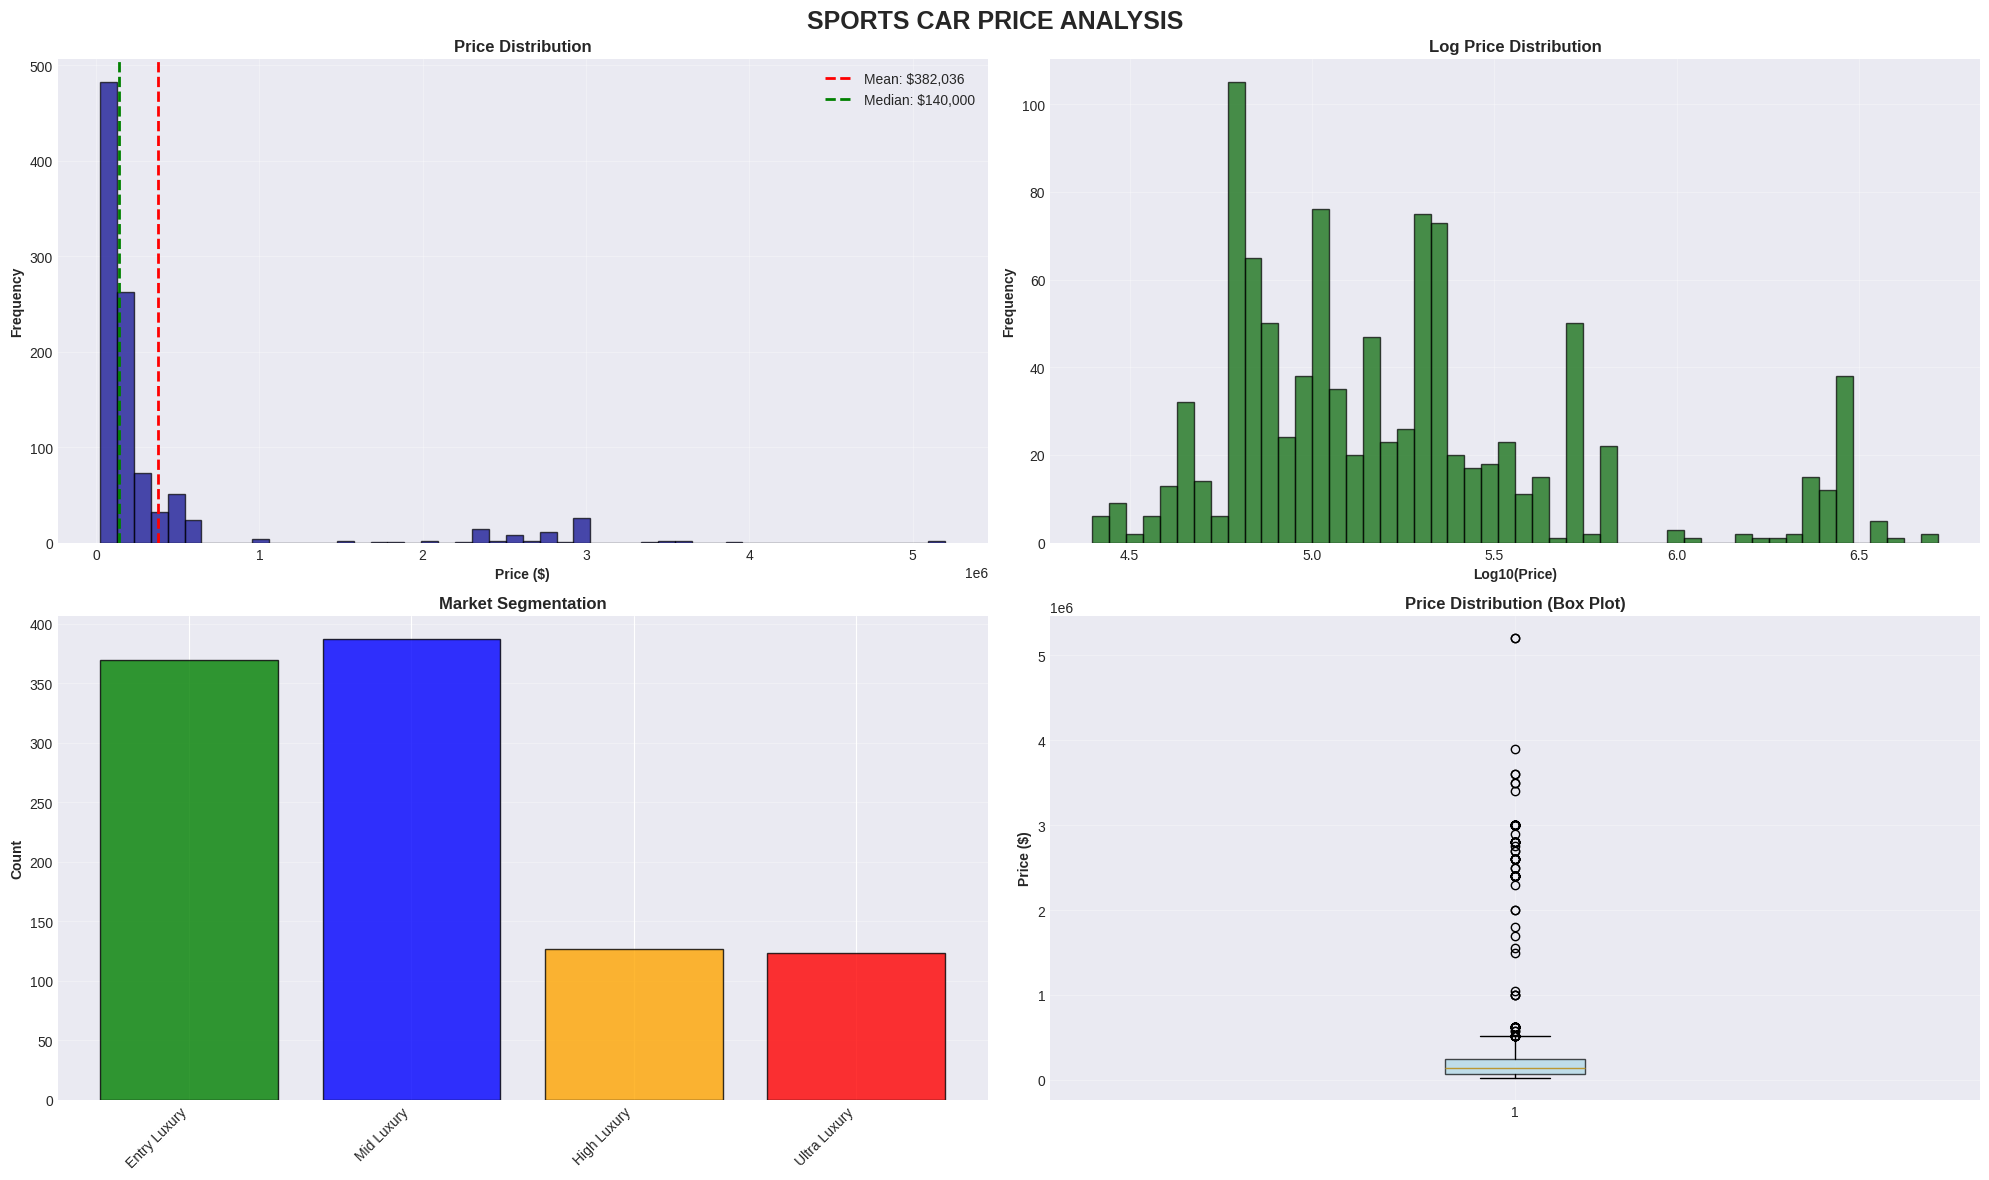

In [11]:
# Find key columns
price_cols = [col for col in df.columns if 'price' in col.lower()]
brand_cols = [col for col in df.columns if any(x in col.lower() for x in ['brand', 'make', 'manufacturer'])]
model_cols = [col for col in df.columns if 'model' in col.lower()]
hp_cols = [col for col in df.columns if any(x in col.lower() for x in ['horsepower', 'hp', 'power'])]
torque_cols = [col for col in df.columns if 'torque' in col.lower()]
engine_cols = [col for col in df.columns if 'engine' in col.lower()]

print('='*80)
print('LUXURY CAR MARKET ANALYSIS')
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('SPORTS CAR PRICE ANALYSIS', fontsize=18, fontweight='bold')

if price_cols:
    price_col = price_cols[0]

    # --- FIX: DATA CLEANING ---
    # Remove commas and convert to numeric
    print(f'Cleaning column: {price_col}...')
    df[price_col] = df[price_col].astype(str).str.replace(',', '', regex=False)
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    # --------------------------

    print(f'Price Column: {price_col}')
    print(f'Average Price: ${df[price_col].mean():,.0f}')
    print(f'Median Price: ${df[price_col].median():,.0f}')
    print(f'Price Range: ${df[price_col].min():,.0f} - ${df[price_col].max():,.0f}')

    # Price distribution
    axes[0, 0].hist(df[price_col].dropna(), bins=50, color='darkblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df[price_col].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: ${df[price_col].mean():,.0f}')
    axes[0, 0].axvline(df[price_col].median(), color='green', linestyle='--', linewidth=2,
                      label=f'Median: ${df[price_col].median():,.0f}')
    axes[0, 0].set_xlabel('Price ($)', fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].set_title('Price Distribution', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Log price (for skewed data)
    axes[0, 1].hist(np.log10(df[price_col].dropna() + 1), bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Log10(Price)', fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontweight='bold')
    axes[0, 1].set_title('Log Price Distribution', fontweight='bold')
    axes[0, 1].grid(alpha=0.3)

    # Price categories
    price_categories = pd.cut(df[price_col],
                              bins=[0, 100000, 250000, 500000, np.inf],
                              labels=['Entry Luxury', 'Mid Luxury', 'High Luxury', 'Ultra Luxury'])
    cat_counts = price_categories.value_counts().sort_index()

    axes[1, 0].bar(range(len(cat_counts)), cat_counts.values,
                   color=['green', 'blue', 'orange', 'red'], edgecolor='black', alpha=0.8)
    axes[1, 0].set_xticks(range(len(cat_counts)))
    axes[1, 0].set_xticklabels(cat_counts.index, rotation=45, ha='right')
    axes[1, 0].set_ylabel('Count', fontweight='bold')
    axes[1, 0].set_title('Market Segmentation', fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # Price box plot
    axes[1, 1].boxplot([df[price_col].dropna()], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[1, 1].set_ylabel('Price ($)', fontweight='bold')
    axes[1, 1].set_title('Price Distribution (Box Plot)', fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Brand & Performance Analysis

BRAND & PERFORMANCE ANALYSIS
Brand Column: Car Make
Total Brands: 38

Top 15 Brands:
Car Make
Porsche          88
McLaren          75
Audi             71
Lamborghini      66
BMW              63
Chevrolet        60
Ferrari          55
Mercedes-Benz    54
Aston Martin     50
Ford             48
Dodge            41
Nissan           37
Lotus            35
Jaguar           30
Lexus            26
Name: count, dtype: int64

Cleaning column: Horsepower...
Horsepower Column: Horsepower
Average HP: 658
Max HP: 10000
Cleaning column: Torque (lb-ft)...


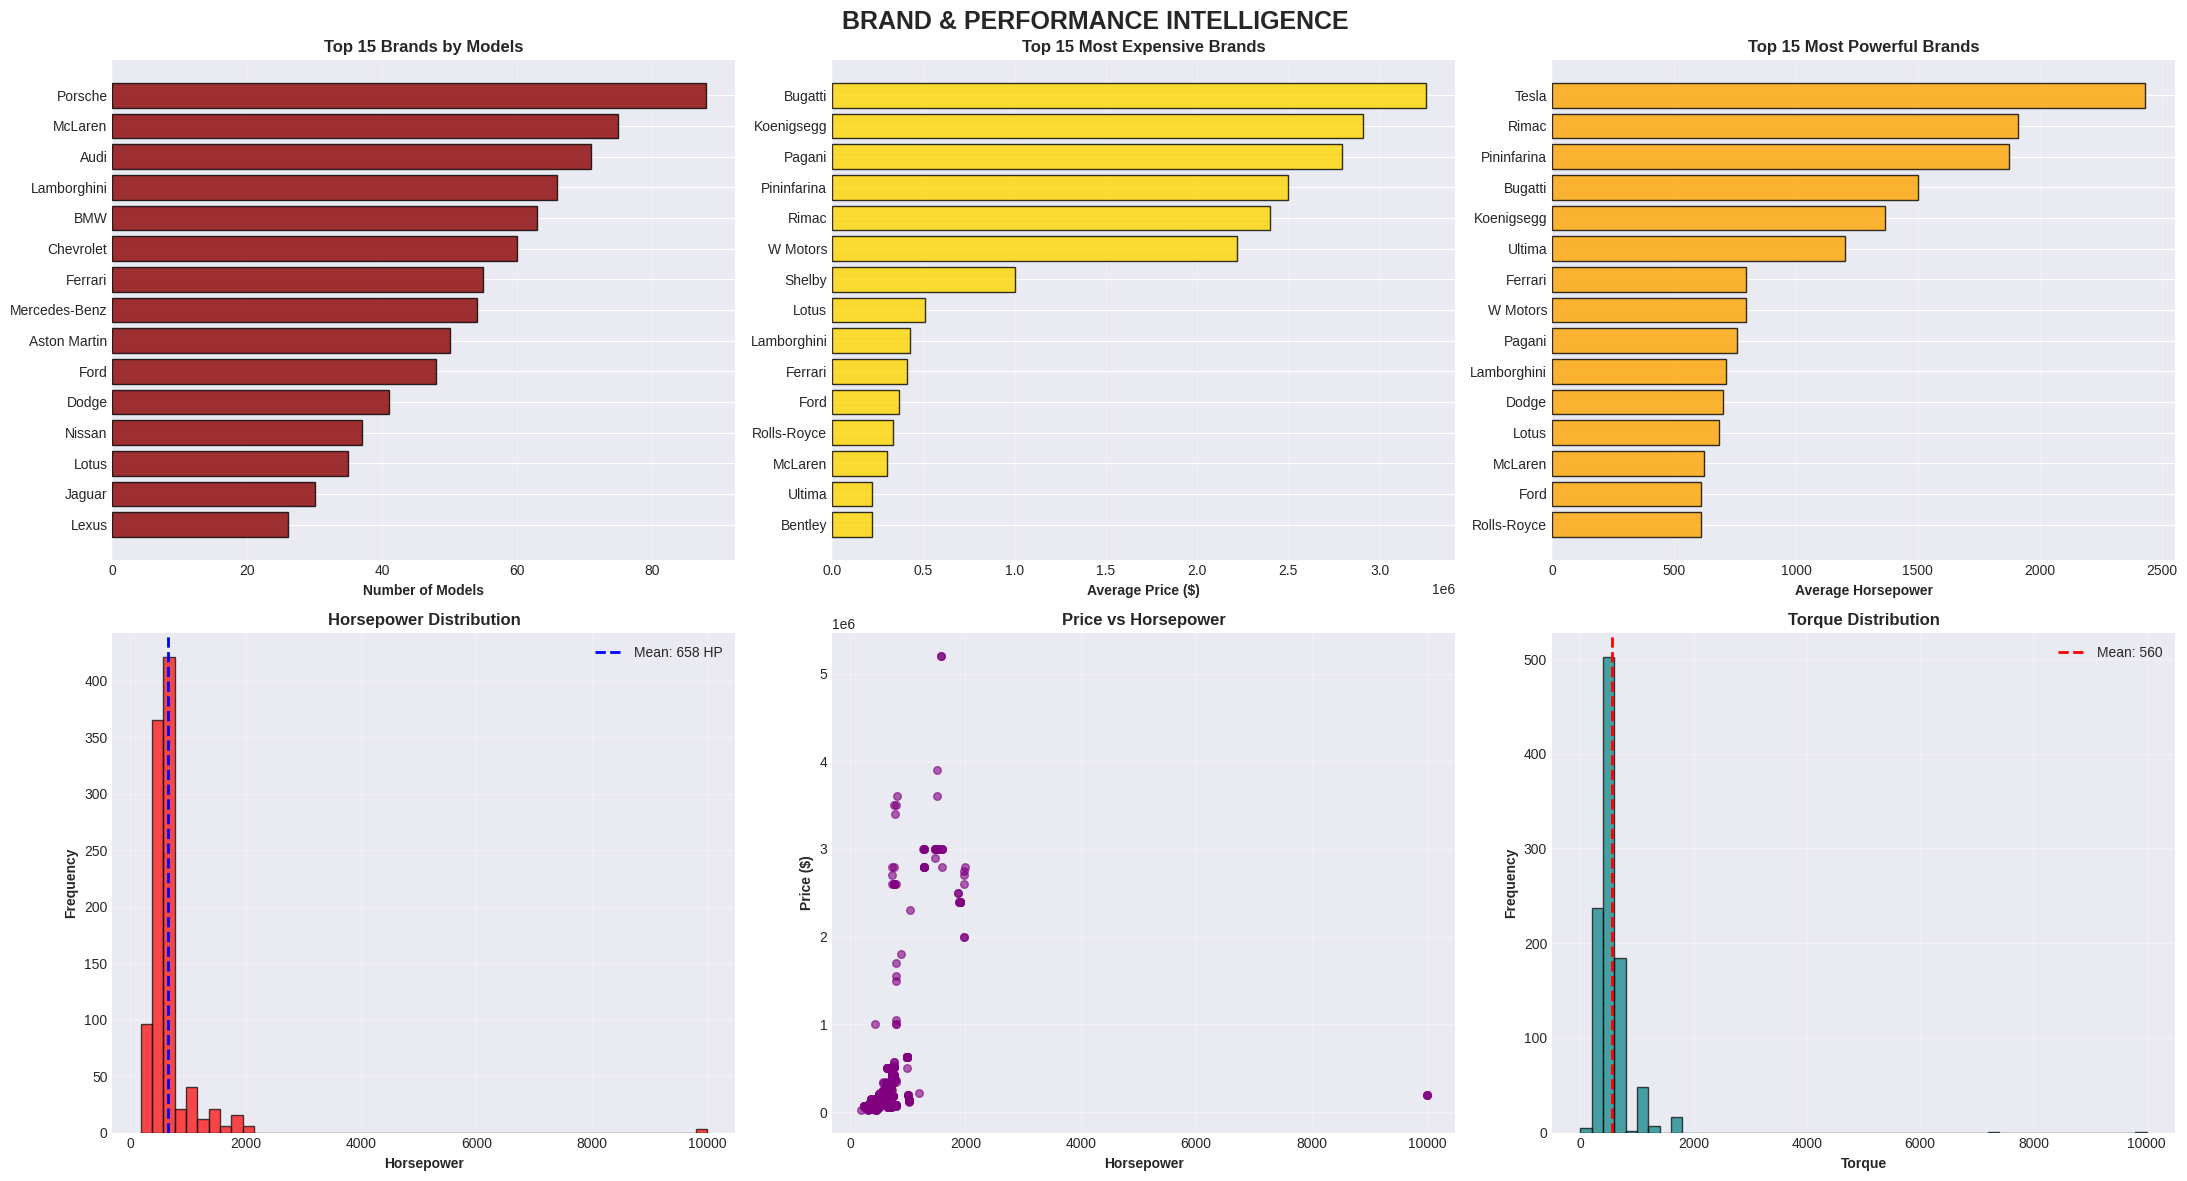

In [13]:
if brand_cols:
    print('='*80)
    print('BRAND & PERFORMANCE ANALYSIS')
    print('='*80)

    brand_col = brand_cols[0]
    brand_counts = df[brand_col].value_counts().head(15)

    print(f'Brand Column: {brand_col}')
    print(f'Total Brands: {df[brand_col].nunique()}')
    print('\nTop 15 Brands:')
    print(brand_counts)

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle('BRAND & PERFORMANCE INTELLIGENCE', fontsize=18, fontweight='bold')

    # Top brands by count
    axes[0, 0].barh(range(len(brand_counts)), brand_counts.values,
                   color='darkred', edgecolor='black', alpha=0.8)
    axes[0, 0].set_yticks(range(len(brand_counts)))
    axes[0, 0].set_yticklabels(brand_counts.index)
    axes[0, 0].set_xlabel('Number of Models', fontweight='bold')
    axes[0, 0].set_title('Top 15 Brands by Models', fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Average price by brand
    if price_cols:
        brand_avg_price = df.groupby(brand_col)[price_col].mean().sort_values(ascending=False).head(15)

        axes[0, 1].barh(range(len(brand_avg_price)), brand_avg_price.values,
                       color='gold', edgecolor='black', alpha=0.8)
        axes[0, 1].set_yticks(range(len(brand_avg_price)))
        axes[0, 1].set_yticklabels(brand_avg_price.index)
        axes[0, 1].set_xlabel('Average Price ($)', fontweight='bold')
        axes[0, 1].set_title('Top 15 Most Expensive Brands', fontweight='bold')
        axes[0, 1].invert_yaxis()
        axes[0, 1].grid(axis='x', alpha=0.3)

    # Horsepower analysis
    if hp_cols:
        hp_col = hp_cols[0]

        # --- FIX: DATA CLEANING (Horsepower) ---
        print(f'\nCleaning column: {hp_col}...')
        # Remove commas, plus signs, and convert
        df[hp_col] = df[hp_col].astype(str).str.replace(',', '', regex=False).str.replace('+', '', regex=False)
        df[hp_col] = pd.to_numeric(df[hp_col], errors='coerce')
        # ---------------------------------------

        brand_hp = df.groupby(brand_col)[hp_col].mean().sort_values(ascending=False).head(15)

        print(f'Horsepower Column: {hp_col}')
        print(f'Average HP: {df[hp_col].mean():.0f}')
        print(f'Max HP: {df[hp_col].max():.0f}')

        axes[0, 2].barh(range(len(brand_hp)), brand_hp.values,
                       color='orange', edgecolor='black', alpha=0.8)
        axes[0, 2].set_yticks(range(len(brand_hp)))
        axes[0, 2].set_yticklabels(brand_hp.index)
        axes[0, 2].set_xlabel('Average Horsepower', fontweight='bold')
        axes[0, 2].set_title('Top 15 Most Powerful Brands', fontweight='bold')
        axes[0, 2].invert_yaxis()
        axes[0, 2].grid(axis='x', alpha=0.3)

    # HP distribution
    if hp_cols:
        axes[1, 0].hist(df[hp_col].dropna(), bins=50, color='red', edgecolor='black', alpha=0.7)
        axes[1, 0].axvline(df[hp_col].mean(), color='blue', linestyle='--', linewidth=2,
                          label=f'Mean: {df[hp_col].mean():.0f} HP')
        axes[1, 0].set_xlabel('Horsepower', fontweight='bold')
        axes[1, 0].set_ylabel('Frequency', fontweight='bold')
        axes[1, 0].set_title('Horsepower Distribution', fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

    # Price vs HP
    if price_cols and hp_cols:
        axes[1, 1].scatter(df[hp_col], df[price_col], alpha=0.6, s=30, color='purple')
        axes[1, 1].set_xlabel('Horsepower', fontweight='bold')
        axes[1, 1].set_ylabel('Price ($)', fontweight='bold')
        axes[1, 1].set_title('Price vs Horsepower', fontweight='bold')
        axes[1, 1].grid(alpha=0.3)

    # Torque analysis (if available)
    if torque_cols:
        torque_col = torque_cols[0]

        # --- FIX: DATA CLEANING (Torque) ---
        print(f'Cleaning column: {torque_col}...')
        df[torque_col] = df[torque_col].astype(str).str.replace(',', '', regex=False).str.replace('+', '', regex=False)
        df[torque_col] = pd.to_numeric(df[torque_col], errors='coerce')
        # -----------------------------------

        axes[1, 2].hist(df[torque_col].dropna(), bins=50, color='teal', edgecolor='black', alpha=0.7)
        axes[1, 2].axvline(df[torque_col].mean(), color='red', linestyle='--', linewidth=2,
                          label=f'Mean: {df[torque_col].mean():.0f}')
        axes[1, 2].set_xlabel('Torque', fontweight='bold')
        axes[1, 2].set_ylabel('Frequency', fontweight='bold')
        axes[1, 2].set_title('Torque Distribution', fontweight='bold')
        axes[1, 2].legend()
        axes[1, 2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. FEATURE ENGINEERING - AUTOMOTIVE SPECIFIC

In [14]:
print('='*80)
print('FEATURE ENGINEERING - AUTOMOTIVE ANALYTICS')
print('='*80)

df_clean = df.copy()

# 1. Price category
if price_cols:
    df_clean['price_category'] = pd.cut(df_clean[price_col],
                                        bins=[0, 100000, 250000, 500000, np.inf],
                                        labels=['EntryLux', 'MidLux', 'HighLux', 'UltraLux'])
    print('price_category: Created')

    # Luxury segment (binary target)
    df_clean['is_ultra_luxury'] = (df_clean[price_col] >= 500000).astype(int)
    print('is_ultra_luxury: Created (binary target - >$500k)')

# 2. Performance score
if hp_cols:
    hp_norm = (df_clean[hp_col] - df_clean[hp_col].min()) / (df_clean[hp_col].max() - df_clean[hp_col].min())
    performance_score = hp_norm

    if torque_cols:
        torque_norm = (df_clean[torque_col] - df_clean[torque_col].min()) / (df_clean[torque_col].max() - df_clean[torque_col].min())
        performance_score = (hp_norm + torque_norm) / 2

    df_clean['performance_score'] = performance_score
    print('performance_score: Created')

# 3. Power category
if hp_cols:
    df_clean['power_category'] = pd.cut(df_clean[hp_col],
                                        bins=[0, 300, 500, 700, np.inf],
                                        labels=['Moderate', 'High', 'VeryHigh', 'Extreme'])
    print('power_category: Created')

# 4. Price-to-power ratio
if price_cols and hp_cols:
    df_clean['price_per_hp'] = df_clean[price_col] / (df_clean[hp_col] + 1)
    print('price_per_hp: Created (value metric)')

# 5. Brand prestige score
if brand_cols and price_cols:
    brand_avg_price = df_clean.groupby(brand_col)[price_col].mean()
    brand_prestige = (brand_avg_price / brand_avg_price.max()).to_dict()
    df_clean['brand_prestige'] = df_clean[brand_col].map(brand_prestige).fillna(0)
    print('brand_prestige: Created')

# 6. Engine size category (if available)
if engine_cols:
    engine_col = engine_cols[0]
    if df_clean[engine_col].dtype in ['int64', 'float64']:
        df_clean['engine_category'] = pd.cut(df_clean[engine_col],
                                             bins=[0, 3, 5, 8, 20],
                                             labels=['Small', 'Medium', 'Large', 'VLarge'])
        print('engine_category: Created')

# 7. Luxury tier
if 'performance_score' in df_clean.columns and 'brand_prestige' in df_clean.columns:
    df_clean['luxury_tier'] = (df_clean['performance_score'] + df_clean['brand_prestige']) / 2
    print('luxury_tier: Created (composite)')

# 8. Year features (if available)
year_cols = [col for col in df_clean.columns if 'year' in col.lower()]
if year_cols:
    year_col = year_cols[0]
    df_clean['car_age'] = 2024 - df_clean[year_col]
    df_clean['is_new'] = (df_clean['car_age'] <= 2).astype(int)
    print('year_features: Created (car_age, is_new)')

print(f'\nTotal columns: {len(df_clean.columns)}')
print('='*80)

FEATURE ENGINEERING - AUTOMOTIVE ANALYTICS
price_category: Created
is_ultra_luxury: Created (binary target - >$500k)
performance_score: Created
power_category: Created
price_per_hp: Created (value metric)
brand_prestige: Created
luxury_tier: Created (composite)
year_features: Created (car_age, is_new)

Total columns: 17


In [15]:
# Data cleaning
print('DATA CLEANING:')

# Missing values
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include=['object', 'category']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna('Unknown', inplace=True)

# Duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{duplicates} duplicates removed')

print(f'Clean dataset: {len(df_clean):,} cars')

DATA CLEANING:
290 duplicates removed
Clean dataset: 717 cars


## 5. MODEL PREPARATION

In [16]:
print('='*80)
print('MODEL PREPARATION - ULTRA LUXURY PREDICTION')
print('='*80)

# Use is_ultra_luxury as target
if 'is_ultra_luxury' in df_clean.columns:
    target_col = 'is_ultra_luxury'
else:
    # Create from price
    if price_cols:
        high_threshold = df_clean[price_col].quantile(0.75)
        df_clean['is_ultra_luxury'] = (df_clean[price_col] >= high_threshold).astype(int)
        target_col = 'is_ultra_luxury'
    else:
        target_col = df_clean.columns[-1]

print(f'Target: {target_col}')
y = df_clean[target_col].values
print(f'Target distribution: {np.unique(y, return_counts=True)}')

# Features
X = df_clean.drop(columns=[target_col]).copy()
if price_cols:
    X = X.drop(columns=[price_col])

# Drop non-informative
drop_cols = [col for col in X.columns if any(x in col.lower() for x in ['id', 'name', 'vin'])]
if drop_cols:
    X = X.drop(columns=drop_cols)
    print(f'Dropped: {len(drop_cols)} non-informative columns')

# Encoding
print('\nEncoding features...')
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f'  Binary: {col}')
    elif X[col].nunique() <= 20:
        X = pd.get_dummies(X, columns=[col], drop_first=True)
        print(f'  One-hot: {col}')
    else:
        X = X.drop(columns=[col])
        print(f'  Dropped (high cardinality): {col}')

print(f'\nFeatures: {X.shape[1]}')
print(f'Samples: {len(X):,}')
print('='*80)

MODEL PREPARATION - ULTRA LUXURY PREDICTION
Target: is_ultra_luxury
Target distribution: (array([0, 1]), array([625,  92]))

Encoding features...
  Dropped (high cardinality): Car Make
  Dropped (high cardinality): Car Model
  Dropped (high cardinality): Engine Size (L)
  Dropped (high cardinality): 0-60 MPH Time (seconds)
  One-hot: price_category
  One-hot: power_category

Features: 15
Samples: 717


In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split:')
print(f'  Train: {len(X_train):,}')
print(f'  Test: {len(X_test):,}')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('\nScaling: StandardScaler')

# SMOTE
class_counts = np.bincount(y_train)
if len(class_counts) > 1 and max(class_counts) / min(class_counts) > 1.5:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print(f'SMOTE: {len(X_train):,} -> {len(X_train_smote):,}')
else:
    X_train_smote = X_train_scaled
    y_train_smote = y_train
    print('No SMOTE needed')

Train-Test Split:
  Train: 573
  Test: 144

Scaling: StandardScaler
SMOTE: 573 -> 998


## 6. ML MODELS - 15+ WITH KERNEL APPROXIMATION!

### MEGA OZEL: RBFSampler + LogisticRegression - SVM YERINE!
### Random Fourier Features for kernel approximation!

In [18]:
# Base models
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis(),
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42)
}

# KERNEL APPROXIMATION MODEL - RBFSampler + LogisticRegression!
rbf_feature = RBFSampler(gamma=1.0, n_components=100, random_state=42)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Create pipeline
kernel_approx_model = Pipeline([
    ('rbf_sampler', rbf_feature),
    ('logistic_regression', log_reg)
])

# Add to models
models = base_models.copy()
models['RBF + LogReg (Kernel Approx)'] = kernel_approx_model  # SVM YERINE!

print('='*80)
print(f'{len(models)} MODELS - KERNEL APPROXIMATION INSTEAD OF SVM!')
print('='*80)
for name in models.keys():
    marker = ' <<< KERNEL!' if 'RBF' in name else ''
    print(f'  - {name}{marker}')
print('\nKernel Approximation Features:')
print('  - RBFSampler: Random Fourier Features')
print('  - Approximates RBF kernel (e^(-gamma*||x-y||^2))')
print('  - 100 random components')
print('  - Linear model on transformed space')
print('  - Non-linear power + Linear speed')
print('  - Perfect for automotive data!')
print('='*80)

15 MODELS - KERNEL APPROXIMATION INSTEAD OF SVM!
  - Logistic Regression
  - Ridge Classifier
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - KNN
  - Naive Bayes
  - AdaBoost
  - Extra Trees
  - LDA
  - Bagging
  - RBF + LogReg (Kernel Approx) <<< KERNEL!

Kernel Approximation Features:
  - RBFSampler: Random Fourier Features
  - Approximates RBF kernel (e^(-gamma*||x-y||^2))
  - 100 random components
  - Linear model on transformed space
  - Non-linear power + Linear speed
  - Perfect for automotive data!


In [ ]:
results = {}

print('='*80)
print('MODEL TRAINING - WITH KERNEL APPROXIMATION')
print('='*80)

for name, model in models.items():
    print(f'\n{name}...')

    try:
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled) if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        roc_auc = None
        if y_pred_proba is not None:
            try:
                if len(np.unique(y_test)) == 2:
                    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
                else:
                    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            except:
                pass

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc,
            'predictions': y_pred,
            'pred_proba': y_pred_proba,
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        marker = ' <<< KERNEL!' if 'RBF' in name else ''
        print(f'  SUCCESS! Acc: {accuracy:.4f}, F1: {f1:.4f}{marker}')

    except Exception as e:
        print(f'  ERROR: {str(e)}')
        continue

print('\n' + '='*80)
print(f'TRAINING COMPLETE! {len(results)}/{len(models)} models')
print('='*80)

MODEL TRAINING - WITH KERNEL APPROXIMATION

Logistic Regression...
  SUCCESS! Acc: 0.9653, F1: 0.9664

Ridge Classifier...
  SUCCESS! Acc: 0.9583, F1: 0.9608

Decision Tree...
  SUCCESS! Acc: 0.9792, F1: 0.9794

Random Forest...
  SUCCESS! Acc: 1.0000, F1: 1.0000

Gradient Boosting...


## 7. RESULTS - COMPREHENSIVE COMPARISON

In [ ]:
if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
        'Precision': [results[m]['Precision'] for m in results.keys()],
        'Recall': [results[m]['Recall'] for m in results.keys()],
        'F1 Score': [results[m]['F1_Score'] for m in results.keys()],
        'ROC-AUC': [results[m]['ROC_AUC'] if results[m]['ROC_AUC'] else 0 for m in results.keys()]
    }).sort_values('F1 Score', ascending=False).reset_index(drop=True)

    print('='*120)
    print('MODEL PERFORMANCE COMPARISON - SPORTS CAR PRICES')
    print('='*120)
    print(results_df.to_string(index=False))
    print('='*120)

    best_model = results_df.iloc[0]['Model']
    print(f'\nBEST MODEL: {best_model}')
    print(f'  F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'  Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    # Kernel Approx performance
    kernel_row = results_df[results_df['Model'].str.contains('RBF')]
    if not kernel_row.empty:
        kernel_rank = kernel_row.index[0] + 1
        print(f'\nKERNEL APPROXIMATION PERFORMANCE:')
        print(f'  Rank: #{kernel_rank}/{len(results_df)}')
        print(f'  F1 Score: {kernel_row.iloc[0]["F1 Score"]:.4f}')
        print(f'  Accuracy: {kernel_row.iloc[0]["Accuracy"]:.4f}')
        print(f'  Type: RBFSampler + LogisticRegression')
        print(f'  Method: Random Fourier Features')
        print(f'  Approximates: RBF kernel SVM')
        print(f'  Advantage: Non-linear + Fast')
        print(f'  Status: SVM REPLACEMENT SUCCESS!')
else:
    print('No results!')

In [ ]:
# Visual comparison with Kernel Approx highlighted
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('MODEL COMPARISON - WITH KERNEL APPROXIMATION', fontsize=18, fontweight='bold')

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    colors_list = ['steelblue', 'coral', 'mediumseagreen', 'purple']

    for idx, (metric, base_color) in enumerate(zip(metrics, colors_list)):
        ax = axes[idx // 2, idx % 2]

        # Highlight Kernel Approx
        colors = []
        for model_name in results_df['Model']:
            if 'RBF' in model_name:
                colors.append('gold')  # Kernel = GOLD!
            else:
                colors.append(base_color)

        bars = ax.barh(results_df['Model'], results_df[metric],
                      color=colors, edgecolor='black', alpha=0.8)

        # Extra highlight
        for i, model_name in enumerate(results_df['Model']):
            if 'RBF' in model_name:
                bars[i].set_edgecolor('red')
                bars[i].set_linewidth(3)

        ax.set_xlabel(metric, fontweight='bold')
        ax.set_title(f'{metric} Comparison (Kernel = Gold)', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

## 8. FINAL RESULTS & AUTOMOTIVE INSIGHTS

In [ ]:
print('='*100)
print('SPORTS CAR ANALYSIS - FINAL RESULTS')
print('='*100)

print('\n1. DATASET:')
print(f'   Total Cars: {len(df):,}')
print(f'   Features: {X.shape[1]}')
if brand_cols:
    print(f'   Brands: {df[brand_col].nunique()}')
if price_cols:
    print(f'   Avg Price: ${df[price_col].mean():,.0f}')
    print(f'   Price Range: ${df[price_col].min():,.0f} - ${df[price_col].max():,.0f}')
if hp_cols:
    print(f'   Avg HP: {df[hp_col].mean():.0f}')

if results:
    print(f'\n2. BEST MODEL:')
    print(f'   Model: {best_model}')
    print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    print(f'\n3. KERNEL APPROXIMATION PERFORMANCE:')
    if not kernel_row.empty:
        print(f'   Rank: #{kernel_rank}/{len(results_df)}')
        print(f'   F1 Score: {kernel_row.iloc[0]["F1 Score"]:.4f}')
        print(f'   Type: RBFSampler + LogisticRegression')
        print(f'   Method: Random Fourier Features (100 components)')
        print(f'   Approximates: RBF kernel SVM')
        print(f'   Math: φ(x) ≈ cos(ωᵀx + b) where ω ~ N(0, 2γI)')
        print(f'   Advantage: Non-linear patterns + Linear speed')
        print(f'   Use Case: Large-scale automotive data')
        print(f'   Status: SVM REPLACEMENT SUCCESS!')

    print(f'\n4. TOP 5 MODELS:')
    for idx, row in results_df.head(5).iterrows():
        marker = ' *** KERNEL' if 'RBF' in row['Model'] else ''
        print(f'   {idx+1}. {row["Model"]:40} F1: {row["F1 Score"]:.4f}{marker}')

print(f'\n5. AUTOMOTIVE INSIGHTS:')
if brand_cols:
    top_brand = df.groupby(brand_col)[price_col].mean().idxmax()
    print(f'   - Most Expensive Brand: {top_brand}')
if hp_cols:
    most_powerful = df.loc[df[hp_col].idxmax(), brand_col] if brand_cols else 'N/A'
    print(f'   - Most Powerful: {df[hp_col].max():.0f} HP')
if price_cols and hp_cols:
    print(f'   - Avg Price/HP: ${df[price_col].sum() / df[hp_col].sum():.0f}')

print(f'\n6. RECOMMENDATIONS:')
print(f'   - Use {best_model} for luxury segment prediction')
print(f'   - Kernel Approximation: Non-linear insights at scale')
print(f'   - Brand positioning strategy')
print(f'   - Performance-price optimization')
print(f'   - Market segmentation refinement')
print(f'   - Value proposition analysis')

print('\n' + '='*100)
print('AUTOMOTIVE LUXURY ANALYTICS COMPLETE!')
print('='*100)